In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import os, glob
import ROOT
from scipy import stats

try:
#     plt.style.use('belle2')
    plt.style.use('belle2_serif')
#     plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style")   
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np
from main.draw_tools.decorations import b2helix, watermark
from main.draw_tools.stacking_with_error_bars import MC_stack_plot, MC_stack_plot_density, MC_stack_plot_weight

from main.data_tools.error_bars import make_data_weight
from main.data_tools.query_dataframes import cut_dfs_7types

Welcome to JupyROOT 6.26/04


In [2]:
# 사용자 함수들 (get_pd, b2helix, MC_stack_plot_weight) 등은 기존 그대로 import 필요
# 예시에서는 get_pd는 ROOT 파일을 pandas로 변환하는 사용자 함수라고 가정

def load_root_files(dir_list, tags, tree, cut, variables):
    file_map = {tag: [] for tag in tags}
    for tag in tags:
        for d in dir_list:
            path = os.path.join(d, f"weighted_{tag}.BCS.root")
            if os.path.exists(path):
                file_map[tag].append(path)
    dataframes = {}
    for tag in tags:
        dfs = [get_pd(file=fp, tree=tree, base_filter=cut, variables=variables) for fp in file_map[tag]]
        df = pd.concat(dfs, ignore_index=True)
        df["ds_weight"] *= 1/4  # Scale weights
        dataframes[tag] = df.query(cut)
    return dataframes

def load_data_files(data_dir_list, tree, cut, variables):
    dfs = []
    for d in data_dir_list:
        for file in glob.glob(os.path.join(d, "*.BCS.root")):
            try:
                dfs.append(get_pd(file=file, tree=tree, base_filter=cut, variables=variables))
            except Exception as e:
                print(f"[Warn] Cannot load {file}:", e)
    return pd.concat(dfs, ignore_index=True)

def plot_stack_with_data(dataframes, tag_order, labels, data_df, var, bins, xlabel, output):
    data_list = [dataframes[tag][var] for tag in tag_order]
    scale_list = [dataframes[tag]["ds_weight"] for tag in tag_order]
    colors = b2helix(len(data_list))

    xbins = np.linspace(*bins, 101)
    bin_centers = (xbins[1:] + xbins[:-1]) / 2
    bin_width = xbins[1] - xbins[0]

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Stack plot (✔ label 순서 그대로)
    ax.hist(data_list, bins=xbins, weights=scale_list, stacked=True, label=labels,
            histtype='stepfilled', color=colors, edgecolor='black')
    
    # MC stat. error
    flat_data = np.concatenate([np.asarray(d) for d in data_list])
    flat_weights = np.concatenate([np.asarray(w) for w in scale_list])
    sum_w = stats.binned_statistic(flat_data, flat_weights, bins=xbins, statistic="sum")[0]
    sum_w2 = stats.binned_statistic(flat_data, flat_weights**2, bins=xbins, statistic="sum")[0]
    ax.bar(bin_centers, 2*np.sqrt(sum_w2), width=bin_width, bottom=sum_w - np.sqrt(sum_w2),
           color='black', hatch='////', fill=False, lw=0, label="MC stat. unc.")

    # Data points
    data_hist, _ = np.histogram(data_df[var], bins=xbins)
    ax.errorbar(bin_centers, data_hist, yerr=np.sqrt(data_hist), fmt='ko', markersize=4, label="Data")
    
    ax.set_xlim(*bins)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(f"Entries / ({bin_width:.4f} GeV/$c^2$)")
    ax.legend(loc="upper left", ncol=2, prop={'size':13})
    plt.tight_layout()
    plt.savefig(output)
    plt.show()


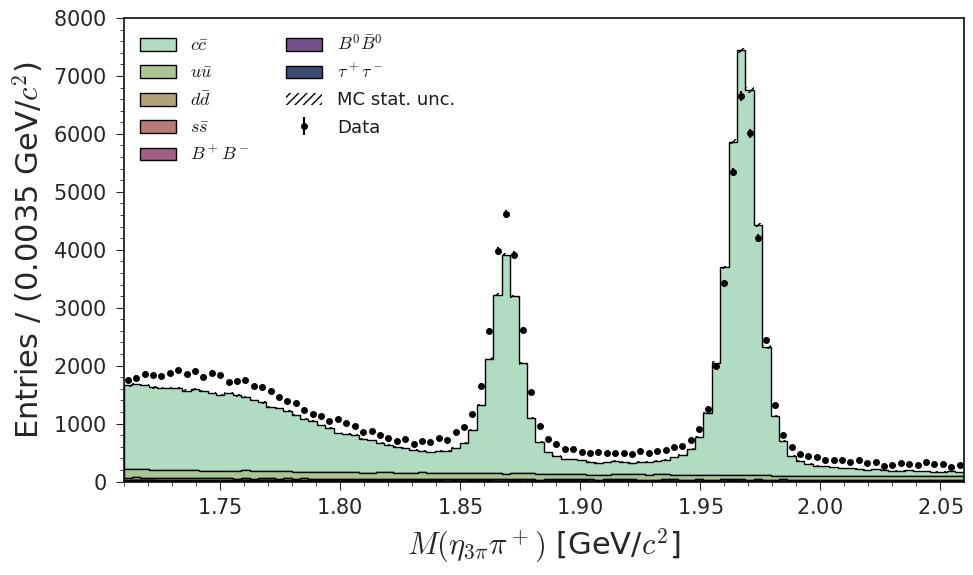

In [9]:


# ================== MAIN SCRIPT ===================

plot_dir = "/media/jykim/T7/saved_plots/DRAW/etapip/MC15rd_generic/pipipi"
os.makedirs(plot_dir, exist_ok=True)

# Settings
tree = "etapip_pipipi"
cut = "Dp_M>0"
variables = ["Dp_M", "ds_weight"]
var = "Dp_M"
bins = (1.71, 2.06)
xlabel = r"$M(\eta_{3\pi}\pi^+)$ [GeV/$c^2$]"
output = os.path.join(plot_dir, "MC15rd_etapip_pipipi_stack_with_data.png")

# MC 설정
tags = ['ccbar', 'uubar', 'ddbar', 'ssbar', 'charged', 'mixed', 'taupair']
tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar']
labels = [r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']

mc_base = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p_v3"
mc_dirs = [f"{mc_base}/15rd_eta_{e}/{tree}/min_unc_search/0.75/weighted" for e in
           ["e7_18_4S_v3", "e20_b26_v1", "e20_e26_4S_v2", "e21_5S_scan_v1", "mori_off_v1"]]
mc_data = load_root_files(mc_dirs, tags, tree, cut, variables)

# 실데이터
data_base = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250216_CMS_Psum_v3"
data_dirs = [f"{data_base}/{d}/{tree}/min_unc_search/0.75" for d in [
    "etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1",
    "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1", "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"
]]
data_df = load_data_files(data_dirs, tree, cut, [var])

# 플롯
plot_stack_with_data(mc_data, tag_order, labels, data_df, var, bins, xlabel, output)

In [4]:
def load_root_files(dir_list, tags, tree, cut, variables):
    file_map = {tag: [] for tag in tags}
    for tag in tags:
        for d in dir_list:
            path = os.path.join(d, f"weighted_{tag}.BCS.root")
            if os.path.exists(path):
                file_map[tag].append(path)

    dataframes = {}
    for tag in tags:
        dfs = [get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ["Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID"]) for fp in file_map[tag]]
        df = pd.concat(dfs, ignore_index=True)
        df["ds_weight"] *= 1/4  # Scale weights
        
        # ccbar 분리
        if tag == "ccbar":
            df_signal = df.query("Dp_isSignal == 1").copy()
            df_signal["ds_weight"] = df_signal["ds_weight"]  # 그대로 유지
            df_signal.drop(columns="Dp_isSignal", inplace=True)

            # df_bkg = df.query("etapip_Eta_isSignal == 1 & (Pip_genMotherID==etapip_Eta_genMotherID) & (Pip_genMotherPDG==431 | Pip_genMotherPDG==-431)").copy()
            # df_bkg = df.query("etapip_Eta_isSignal == 1 & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431) | (Pip_genMotherPDG == -431))").copy()
            df_bkg = df.query("(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )").copy()

            df_bkg["ds_weight"] = df_bkg["ds_weight"]
            df_bkg.drop(columns="Dp_isSignal", inplace=True)

            df_bkg2 = df.query("(Dp_isSignal != 1) and ((etapip_Eta_isSignal != 1) or (Pip_genMotherID != etapip_Eta_genMotherID) or ((Pip_genMotherPDG != 431 or Pip_mcPDG != 211) and (Pip_genMotherPDG != -431 or Pip_mcPDG != -211) ) )").copy()
            df_bkg2["ds_weight"] = df_bkg2["ds_weight"]
            df_bkg2.drop(columns="Dp_isSignal", inplace=True)           

            dataframes["ccbar_sig"] = df_signal.query(cut)
            dataframes["ccbar_bkg"] = df_bkg.query(cut)
            dataframes["ccbar_bkg2"] = df_bkg2.query(cut)
        else:
            df.drop(columns="Dp_isSignal", inplace=True)
            dataframes[tag] = df.query(cut)

    return dataframes

def load_data_files(data_dir_list, tree, cut, variables):
    dfs = []
    for d in data_dir_list:
        for file in glob.glob(os.path.join(d, "*.BCS.root")):
            try:
                dfs.append(get_pd(file=file, tree=tree, base_filter=cut, variables=variables))
            except Exception as e:
                print(f"[Warn] Cannot load {file}:", e)
    return pd.concat(dfs, ignore_index=True)

def plot_stack_with_data(dataframes, tag_order, labels, data_df, var, bins, xlabel, output):
    data_list = [dataframes[tag][var] for tag in tag_order]
    scale_list = [dataframes[tag]["ds_weight"] for tag in tag_order]
    colors = b2helix(len(data_list))

    xbins = np.linspace(*bins, 101)
    bin_centers = (xbins[1:] + xbins[:-1]) / 2
    bin_width = xbins[1] - xbins[0]

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Stack plot (✔ label 순서 그대로)
    ax.hist(data_list, bins=xbins, weights=scale_list, stacked=True, label=labels,
            histtype='stepfilled', color=colors, edgecolor='black')
    
    # MC stat. error
    flat_data = np.concatenate([np.asarray(d) for d in data_list])
    flat_weights = np.concatenate([np.asarray(w) for w in scale_list])
    sum_w = stats.binned_statistic(flat_data, flat_weights, bins=xbins, statistic="sum")[0]
    sum_w2 = stats.binned_statistic(flat_data, flat_weights**2, bins=xbins, statistic="sum")[0]
    ax.bar(bin_centers, 2*np.sqrt(sum_w2), width=bin_width, bottom=sum_w - np.sqrt(sum_w2),
           color='black', hatch='////', fill=False, lw=0, label="MC stat. unc.")

    # Data points
    data_hist, _ = np.histogram(data_df[var], bins=xbins)
    ax.errorbar(bin_centers, data_hist, yerr=np.sqrt(data_hist), fmt='ko', markersize=4, label="Data")
    
    ax.set_xlim(*bins)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(f"Entries / ({bin_width:.4f} GeV/$c^2$)")
    ax.legend(loc="upper left", ncol=2, prop={'size':13})
    plt.tight_layout()
    plt.savefig(output)
    plt.show()


In [5]:
tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar_bkg2', 'ccbar_bkg', 'ccbar_sig']
labels = [
    r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$',
    r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$',
    r'other $c\bar{c}$', r'$D^+_s$ signal',  r'$D^+$ signal'
]


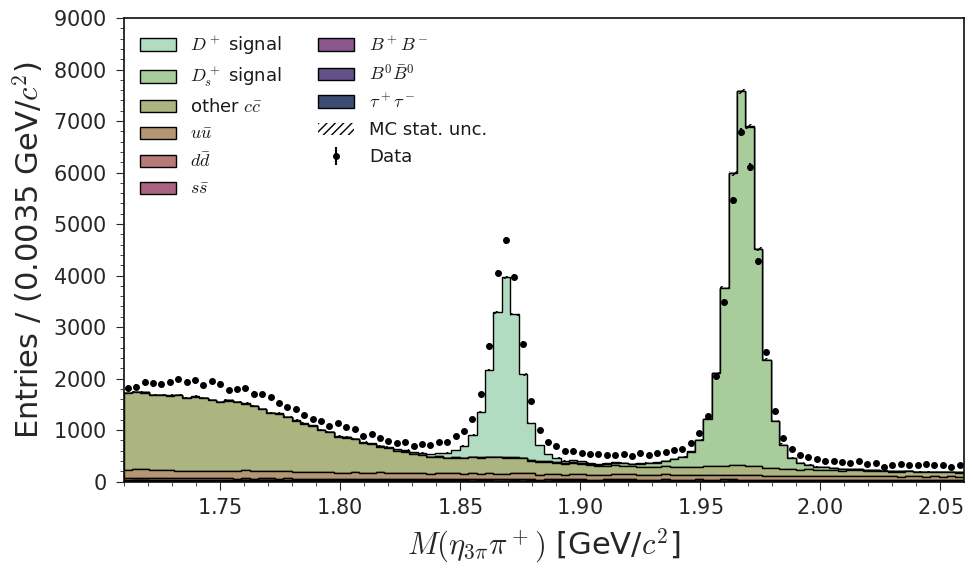

Error in <TList::Clear>: A list is accessing an object (0x56011f59d7b0) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x56011f5a33d0) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x56011f5a3740) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x56011f5a3ab0) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x56011f5a3f20) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x56011f5a43c0) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x56011f5a4790) already deleted (list name = TList)


In [6]:

# ================== MAIN SCRIPT ===================

plot_dir = "/media/jykim/T7/saved_plots/DRAW/etapip/MC15rd_generic/pipipi"
os.makedirs(plot_dir, exist_ok=True)

# Settings
tree = "etapip_pipipi"
cut = "Dp_M>0"
variables = ["Dp_M", "ds_weight"]
var = "Dp_M"
bins = (1.71, 2.06)
xlabel = r"$M(\eta_{3\pi}\pi^+)$ [GeV/$c^2$]"
output = os.path.join(plot_dir, "MC15rd_etapip_pipipi_stack_with_data_new_Ds_correct_74.png")
# output = "test.png"

# MC 설정
tags = ['ccbar', 'uubar', 'ddbar', 'ssbar', 'charged', 'mixed', 'taupair']
# tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar']
# labels = [r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']

mc_base = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p_v3"
mc_dirs = [f"{mc_base}/15rd_eta_{e}/{tree}/min_unc_search/0.74/weighted" for e in
           ["e7_18_4S_v3", "e20_b26_v1", "e20_e26_4S_v2", "e21_5S_scan_v1", "mori_off_v1"]]
mc_data = load_root_files(mc_dirs, tags, tree, cut, variables)

# 실데이터
data_base = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250216_CMS_Psum_v3"
data_dirs = [f"{data_base}/{d}/{tree}/min_unc_search/0.74" for d in [
    "etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1",
    "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1", "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"
]]
data_df = load_data_files(data_dirs, tree, cut, [var])

# 플롯
plot_stack_with_data(mc_data, tag_order, labels, data_df, var, bins, xlabel, output)

In [7]:
# separate Ds+ -> rho+ eta

In [17]:
def load_root_files(dir_topo_list, dir_list, tags, tree, cut, variables):
    file_map = {tag: [] for tag in tags}
    for tag in tags:
        if tag != "ccbar":
            for d in dir_list:
                path = os.path.join(d, f"weighted_{tag}.BCS.root")
                if os.path.exists(path):
                    file_map[tag].append(path)
        else:
            for d in dir_topo_list:
                path = os.path.join(d, f"standard.root")
                if os.path.exists(path):
                    file_map[tag].append(path)            

    dataframes = {}
    for tag in tags:
        # ccbar 분리
        if tag == "ccbar":
            dfs = [get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['nAllSigCascDcyBr_16', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID"]) for fp in file_map[tag]]
            df = pd.concat(dfs, ignore_index=True)
            df["ds_weight"] *= 1/4  # Scale weights
            
            df_signal = df.query("Dp_isSignal == 1").copy()
            df_signal["ds_weight"] = df_signal["ds_weight"]  # 그대로 유지
            df_signal.drop(columns="Dp_isSignal", inplace=True)

            # df_bkg = df.query("etapip_Eta_isSignal == 1 & (Pip_genMotherID==etapip_Eta_genMotherID) & (Pip_genMotherPDG==431 | Pip_genMotherPDG==-431)").copy()
            # df_bkg = df.query("etapip_Eta_isSignal == 1 & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431) | (Pip_genMotherPDG == -431))").copy()
            df_bkg = df.query("(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )").copy()

            df_bkg["ds_weight"] = df_bkg["ds_weight"]
            df_bkg.drop(columns="Dp_isSignal", inplace=True)

            df_bkg2 = df.query("(nAllSigCascDcyBr_16 <= 0) and (Dp_isSignal != 1) and ((etapip_Eta_isSignal != 1) or (Pip_genMotherID != etapip_Eta_genMotherID) or ((Pip_genMotherPDG != 431 or Pip_mcPDG != 211) and (Pip_genMotherPDG != -431 or Pip_mcPDG != -211) ) )").copy()
            df_bkg2["ds_weight"] = df_bkg2["ds_weight"]
            df_bkg2.drop(columns="Dp_isSignal", inplace=True)           


            df_bkg3 = df.query("(nAllSigCascDcyBr_16 > 0 ) and (Dp_isSignal != 1) and ((etapip_Eta_isSignal != 1) or (Pip_genMotherID != etapip_Eta_genMotherID) or ((Pip_genMotherPDG != 431 or Pip_mcPDG != 211) and (Pip_genMotherPDG != -431 or Pip_mcPDG != -211) ) )").copy()
            df_bkg3["ds_weight"] = df_bkg3["ds_weight"]
            df_bkg3.drop(columns="Dp_isSignal", inplace=True)
            
            dataframes["ccbar_sig"] = df_signal.query(cut)
            dataframes["ccbar_sig_Ds"] = df_bkg.query(cut)
            dataframes["ccbar_bkg_comb"] = df_bkg2.query(cut)
            dataframes["ccbar_bkg_rhopeta"] = df_bkg3.query(cut)
        else:
            dfs = [get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ["Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID"]) for fp in file_map[tag]]
            df = pd.concat(dfs, ignore_index=True)
            df["ds_weight"] *= 1/4  # Scale weights
            
            df.drop(columns="Dp_isSignal", inplace=True)
            dataframes[tag] = df.query(cut)

    return dataframes

def load_data_files(data_dir_list, tree, cut, variables):
    dfs = []
    for d in data_dir_list:
        for file in glob.glob(os.path.join(d, "*.BCS.root")):
            try:
                dfs.append(get_pd(file=file, tree=tree, base_filter=cut, variables=variables))
            except Exception as e:
                print(f"[Warn] Cannot load {file}:", e)
    return pd.concat(dfs, ignore_index=True)

def plot_stack_with_data(dataframes, tag_order, labels, data_df, var, bins, xlabel, output):
    data_list = [dataframes[tag][var] for tag in tag_order]
    scale_list = [dataframes[tag]["ds_weight"] for tag in tag_order]
    colors = b2helix(len(data_list))

    xbins = np.linspace(*bins, 101)
    bin_centers = (xbins[1:] + xbins[:-1]) / 2
    bin_width = xbins[1] - xbins[0]

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Stack plot (✔ label 순서 그대로)
    ax.hist(data_list, bins=xbins, weights=scale_list, stacked=True, label=labels,
            histtype='stepfilled', color=colors, edgecolor='black')
    
    # MC stat. error
    flat_data = np.concatenate([np.asarray(d) for d in data_list])
    flat_weights = np.concatenate([np.asarray(w) for w in scale_list])
    sum_w = stats.binned_statistic(flat_data, flat_weights, bins=xbins, statistic="sum")[0]
    sum_w2 = stats.binned_statistic(flat_data, flat_weights**2, bins=xbins, statistic="sum")[0]
    ax.bar(bin_centers, 2*np.sqrt(sum_w2), width=bin_width, bottom=sum_w - np.sqrt(sum_w2),
           color='black', hatch='////', fill=False, lw=0, label="MC stat. unc.")

    # Data points
    data_hist, _ = np.histogram(data_df[var], bins=xbins)
    ax.errorbar(bin_centers, data_hist, yerr=np.sqrt(data_hist), fmt='ko', markersize=4, label="Data")
    
    ax.set_xlim(*bins)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(f"Entries / ({bin_width:.4f} GeV/$c^2$)")
    ax.legend(loc="upper left", ncol=2, prop={'size':13})
    plt.tight_layout()
    plt.savefig(output)
    plt.show()


In [18]:
tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar_bkg_comb', 'ccbar_bkg_rhopeta', 'ccbar_sig_Ds', 'ccbar_sig']
labels = [
    r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$',
    r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$',
    r'other $c\bar{c}$', r'$D^+_s \to \rho^+ \eta$', r'$D^+_s$ signal',  r'$D^+$ signal'
]


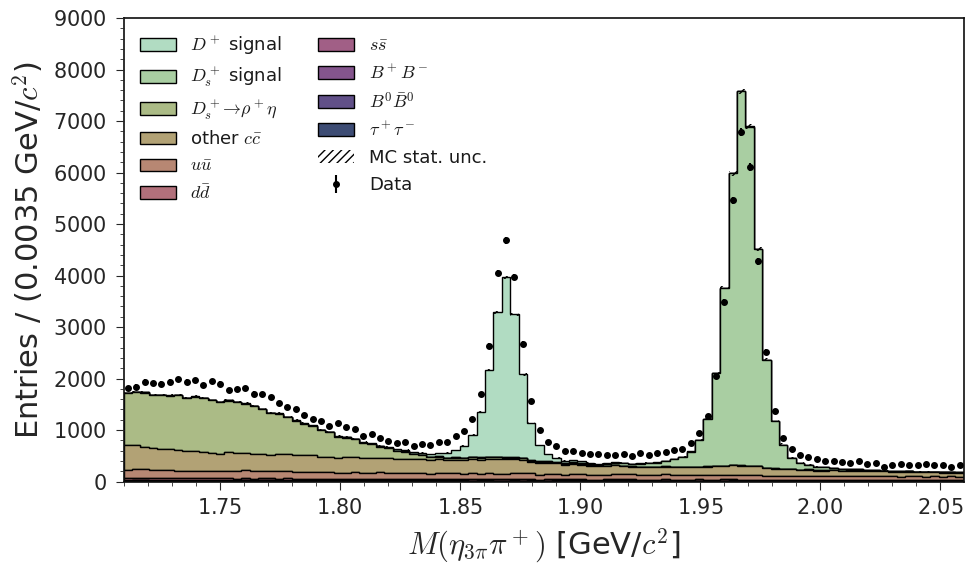

In [19]:

# ================== MAIN SCRIPT ===================

plot_dir = "/media/jykim/T7/saved_plots/DRAW/etapip/MC15rd_generic/pipipi"
os.makedirs(plot_dir, exist_ok=True)

# Settings
tree = "etapip_pipipi"
cut = "Dp_M>0"
variables = ["Dp_M", "ds_weight"]
var = "Dp_M"
bins = (1.71, 2.06)
xlabel = r"$M(\eta_{3\pi}\pi^+)$ [GeV/$c^2$]"
output = os.path.join(plot_dir, "MC15rd_etapip_pipipi_stack_with_data_new_Ds_correct_topoana.png")
# output = "test.png"

# MC 설정
tags = ['ccbar', 'uubar', 'ddbar', 'ssbar', 'charged', 'mixed', 'taupair']
# tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar']
# labels = [r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']

mc_base = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p_v3"
mc_dirs = [f"{mc_base}/15rd_eta_{e}/{tree}/min_unc_search/0.74/weighted" for e in
           ["e7_18_4S_v3", "e20_b26_v1", "e20_e26_4S_v2", "e21_5S_scan_v1", "mori_off_v1"]]
mc_topo_dirs = [f"{mc_base}/topo_BCS_v1/15rd_eta_{e}/resultfile/result_{tree}" for e in
           ["e7_18_4S_v3", "e20_b26_v1", "e20_e26_4S_v2", "e21_5S_scan_v1", "mori_off_v1"]]
mc_data = load_root_files(mc_topo_dirs, mc_dirs, tags, tree, cut, variables)

# 실데이터
data_base = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250216_CMS_Psum_v3"
data_dirs = [f"{data_base}/{d}/{tree}/min_unc_search/0.74" for d in [
    "etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1",
    "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1", "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"
]]
data_df = load_data_files(data_dirs, tree, cut, [var])

# 플롯
plot_stack_with_data(mc_data, tag_order, labels, data_df, var, bins, xlabel, output)